# Projeto: Predição de Popularidade no Spotify

Este notebook apresenta a versão final e mais robusta do nosso modelo de predição de popularidade. 
Sabemos que características puramente sonoras (como ser mais 'dançante' ou 'acústica') ajudam, mas o que realmente dita o sucesso estrondoso de uma música é **quem canta** e o **gênero musical**.

Por isso, vamos focar em construir o modelo definitivo combinando:
1. **Áudio** (Features musicais)
2. **Gênero** (Codificado pela popularidade média)
3. **Artista** (Target Encoding com validação cruzada para evitar 'decoreba' do modelo)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import TargetEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

import warnings
warnings.filterwarnings('ignore')

# Configuração estética padrão para gráficos
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette('viridis')

## 1. Carregamento dos Dados
Aqui importamos o dataset original, removemos colunas desnecessárias e linhas vazias.

In [2]:
import os
data_path = '../data/dataset.csv' if os.path.exists('../data/dataset.csv') else ('data/dataset.csv' if os.path.exists('data/dataset.csv') else 'dataset.csv')
df = pd.read_csv(data_path)
df = df.drop(columns=[df.columns[0], 'track_id'])
df = df.dropna(subset=['artists', 'track_name', 'album_name'])
df.head()

,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## 2. Análise Exploratória de Dados (EDA)

Nesta etapa, realizamos o **Data Profiling (Raio-X Técnico dos Dados)** adotado em engenharia de machine learning para conhecer profundamente a base antes de qualquer transformação:
1. **Sanidade e Integridade:** Verificação de volume (linhas × colunas), tipos de dados, dados nulos e duplicatas.
2. **Cardinalidade:** Volume de categorias distintas (artistas, álbuns, faixas e gêneros) e equilíbrio amostral.
3. **Estatísticas Descritivas:** Análise de tendência central (média e mediana), dispersão (desvio padrão, min, max) e assimetria (*skewness*) das variáveis de áudio.

In [19]:
# 1. DIAGNOSTICO ESTRUTURAL E SANIDADE DOS DADOS (DATA HEALTH CHECK) ===
print("=" * 70)
print(f"DIMENSOES: {df.shape[0]:,} linhas x {df.shape[1]} colunas")
print(f"REGISTROS DUPLICADOS: {df.duplicated().sum()}")
print(f"ARTISTAS DISTINTOS: {df['artists'].nunique():,}")
print(f"ALBUNS DISTINTOS: {df['album_name'].nunique():,}")
print(f"FAIXAS DISTINTAS: {df['track_name'].nunique():,}")
print(f"GENEROS DISTINTOS: {df['track_genre'].nunique():,}")
print(f"BALANCEAMENTO POR GENERO: {df['track_genre'].value_counts().min()} a {df['track_genre'].value_counts().max()} musicas por genero")
print("=" * 70)

# Tabela detalhada de tipos, integridade e cardinalidade de cada coluna
data_profiling = pd.DataFrame({
    'Tipo': df.dtypes.astype(str),
    'Nao-Nulos': df.notnull().sum(),
    'Qtd Nulos': df.isnull().sum(),
    '% Nulos': (df.isnull().sum() / len(df) * 100).round(2),
    'Valores Unicos (Cardinalidade)': df.nunique(),
    'Exemplo de Valor': [str(df[col].iloc[0])[:30] for col in df.columns]
})
print("\nRAIO-X DAS VARIAVEIS (DATA HEALTH CHECK):")
display(data_profiling)

# 2. ESTATISTICAS DESCRITIVAS E ASSIMETRIA DAS FEATURES NUMERICAS ===
stats_num = df.describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]
stats_num['skewness'] = df.skew(numeric_only=True)
stats_num = stats_num.rename(columns={'50%': 'mediana (50%)'})
print("\nRESUMO ESTATISTICO DAS FEATURES NUMERICAS:")
display(stats_num.round(3))

DIMENSOES: 113,999 linhas x 19 colunas
REGISTROS DUPLICADOS: 577
ARTISTAS DISTINTOS: 31,437
ALBUNS DISTINTOS: 46,589
FAIXAS DISTINTAS: 73,608
GENEROS DISTINTOS: 114
BALANCEAMENTO POR GENERO: 999 a 1000 musicas por genero

RAIO-X DAS VARIAVEIS (DATA HEALTH CHECK):


,Tipo,Nao-Nulos,Qtd Nulos,% Nulos,Valores Unicos (Cardinalidade),Exemplo de Valor
artists,str,113999,0,0.0,31437,Gen Hoshino
album_name,str,113999,0,0.0,46589,Comedy
track_name,str,113999,0,0.0,73608,Comedy
popularity,int64,113999,0,0.0,101,73
duration_ms,int64,113999,0,0.0,50696,230666
explicit,bool,113999,0,0.0,2,False
danceability,float64,113999,0,0.0,1174,0.676
energy,float64,113999,0,0.0,2083,0.461
key,int64,113999,0,0.0,12,1
loudness,float64,113999,0,0.0,19480,-6.746



RESUMO ESTATISTICO DAS FEATURES NUMERICAS:


,mean,std,min,25%,mediana (50%),75%,max,skewness
popularity,33.239,22.305,0.000,17.000,35.000,50.000,100.000,0.046
duration_ms,228031.153,107296.058,8586.000,174066.000,212906.000,261506.000,5237295.000,11.196
danceability,0.567,0.174,0.000,0.456,0.580,0.695,0.985,-0.400
energy,0.641,0.252,0.000,0.472,0.685,0.854,1.000,-0.597
key,5.309,3.560,0.000,2.000,5.000,8.000,11.000,-0.008
loudness,-8.259,5.029,-49.531,-10.013,-7.004,-5.003,4.532,-2.007
mode,0.638,0.481,0.000,0.000,1.000,1.000,1.000,-0.572
speechiness,0.085,0.106,0.000,0.036,0.049,0.084,0.965,4.647
acousticness,0.315,0.333,0.000,0.017,0.169,0.597,0.996,0.727
instrumentalness,0.156,0.310,0.000,0.000,0.000,0.049,1.000,1.734


### 2.2. Visualizações Gráficas e Padrões de Popularidade

Após o diagnóstico estrutural, passamos para a exploração visual para entender como a popularidade se comporta graficamente e como as variáveis sonoras interagem entre si.

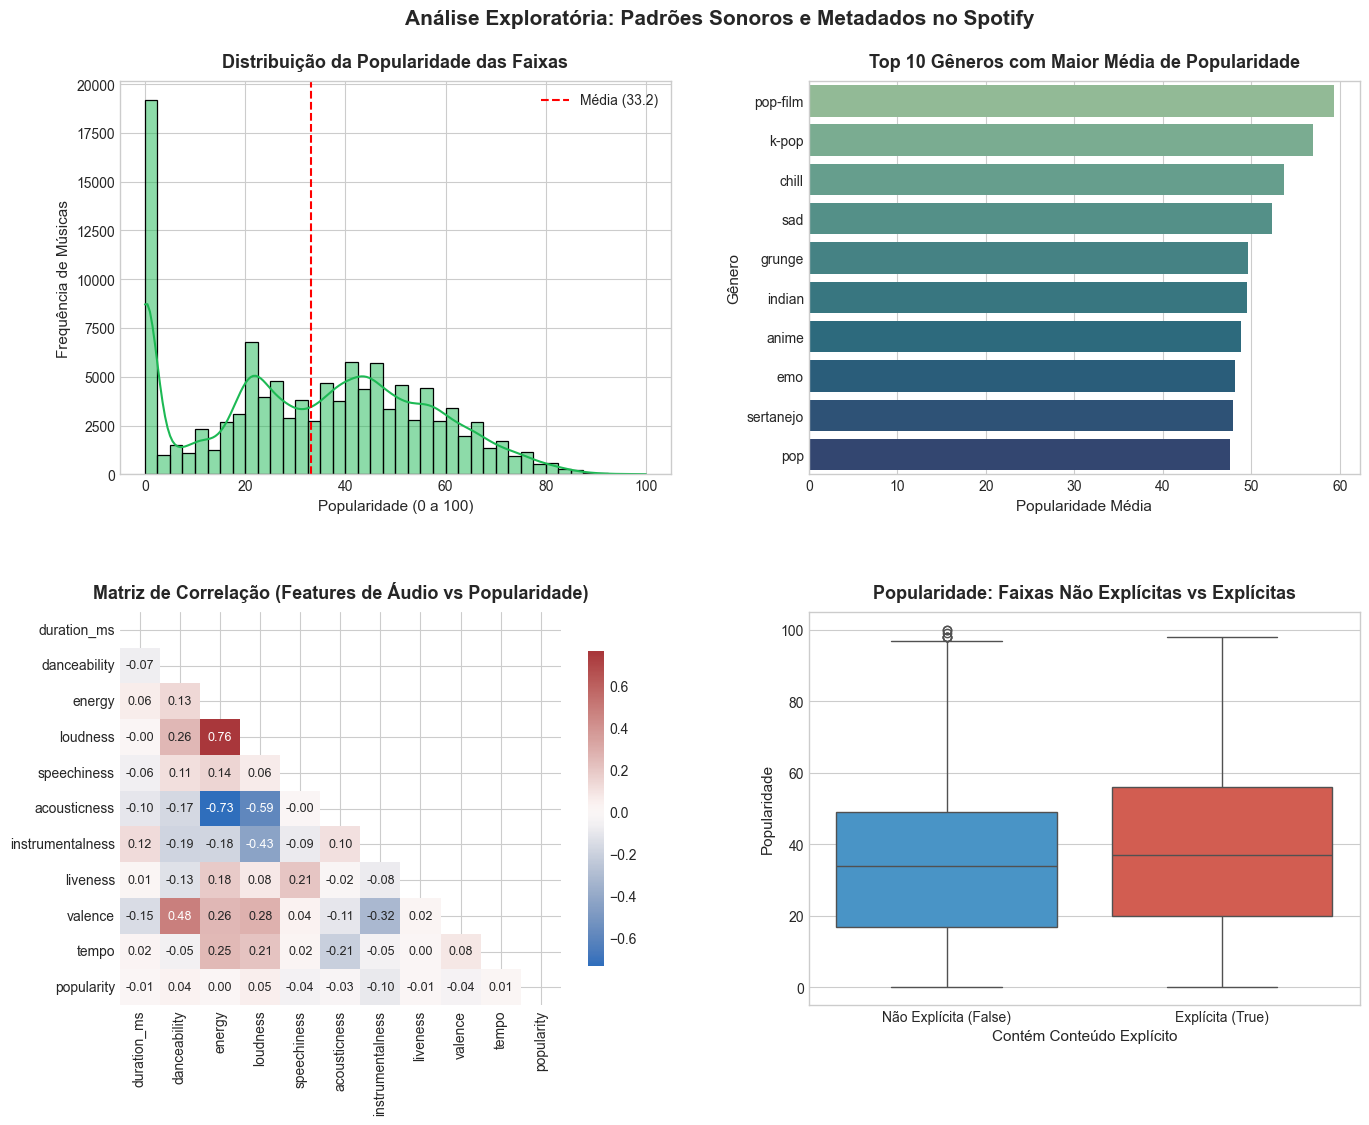

In [15]:
# Visualizações da Análise Exploratória de Dados
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.35, wspace=0.25)

# 1. Distribuição da Popularidade
sns.histplot(df['popularity'], bins=40, kde=True, ax=axes[0, 0], color='#1DB954', edgecolor='black')
axes[0, 0].set_title('Distribuição da Popularidade das Faixas', fontsize=13, fontweight='bold', pad=10)
axes[0, 0].set_xlabel('Popularidade (0 a 100)', fontsize=11)
axes[0, 0].set_ylabel('Frequência de Músicas', fontsize=11)
axes[0, 0].axvline(df['popularity'].mean(), color='red', linestyle='--', label=f'Média ({df["popularity"].mean():.1f})')
axes[0, 0].legend(fontsize=10)

# 2. Top 10 Gêneros com Maior Média de Popularidade
top_genres = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_genres.values, y=top_genres.index, ax=axes[0, 1], palette='crest')
axes[0, 1].set_title('Top 10 Gêneros com Maior Média de Popularidade', fontsize=13, fontweight='bold', pad=10)
axes[0, 1].set_xlabel('Popularidade Média', fontsize=11)
axes[0, 1].set_ylabel('Gênero', fontsize=11)

# 3. Matriz de Correlação das Features Sonoras com a Popularidade
audio_cols = ['duration_ms', 'danceability', 'energy', 'loudness', 'speechiness',
              'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'popularity']
corr_matrix = df[audio_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='vlag', center=0, mask=mask, 
            ax=axes[1, 0], cbar_kws={'shrink': 0.8}, annot_kws={'size': 9})
axes[1, 0].set_title('Matriz de Correlação (Features de Áudio vs Popularidade)', fontsize=13, fontweight='bold', pad=10)

# 4. Popularidade por Conteúdo Explícito
sns.boxplot(x='explicit', y='popularity', data=df, ax=axes[1, 1], palette=['#3498db', '#e74c3c'])
axes[1, 1].set_title('Popularidade: Faixas Não Explícitas vs Explícitas', fontsize=13, fontweight='bold', pad=10)
axes[1, 1].set_xlabel('Contém Conteúdo Explícito', fontsize=11)
axes[1, 1].set_ylabel('Popularidade', fontsize=11)
axes[1, 1].set_xticks([0, 1])
axes[1, 1].set_xticklabels(['Não Explícita (False)', 'Explícita (True)'])

plt.suptitle('Análise Exploratória: Padrões Sonoros e Metadados no Spotify', fontsize=15, fontweight='heavy', y=0.94)
plt.show()

### Principais Insights da Análise Exploratória:
1. **Assimetria e Acúmulo no Zero**: Um grande volume de faixas possui popularidade próxima ou igual a zero (músicas pouco reproduzidas ou de catálogos de nicho), puxando a média geral para baixo (~33 pontos).
2. **Impacto Decisivo do Gênero**: Gêneros como *pop-film*, *k-pop*, *chill* e *grunge* concentram médias de popularidade significativamente superiores à média global do catálogo.
3. **Correlações Fracas nas Características Acústicas**: Isoladamente, atributos acústicos como `danceability`, `energy` e `valence` possuem baixa correlação linear com o índice de popularidade. Isso comprova que **o som isolado não define o sucesso**: metadados de alto nível (identidade do artista e estilo do gênero) são preditores determinantes, justificando nossa estratégia de *Target Encoding*.
4. **Músicas Explícitas**: Faixas com marcação explícita apresentam uma mediana de popularidade ligeiramente superior, comum em gêneros de alta circulação no streaming (como hip-hop, rap e trap).
---

## 3. Divisão Estratégica dos Dados

Para simularmos um ambiente real de machine learning, não podemos treinar e testar nos mesmos dados. Faremos duas separações:
1. **Teste Final (10%)**: Dados que guardaremos a 7 chaves e o modelo só verá no final de tudo.
2. **Treino (81%) e Validação (9%)**: Onde o modelo vai treinar (aprender) e fazer os 'simulados' (validação) para ajustarmos os parâmetros.

In [4]:
X = df.drop(columns=['popularity'])
y = df['popularity']

# 1. Primeira divisão: Separa 10% para o Teste Final definitivo
X_desenvolvimento, X_teste_final, y_desenvolvimento, y_teste_final = train_test_split(
    X, y, test_size=0.10, random_state=42
)

# 2. Segunda divisão: Dos 90% restantes, separamos 10% para Validação e o restante para Treino
X_treino, X_validacao, y_treino, y_validacao = train_test_split(
    X_desenvolvimento, y_desenvolvimento, test_size=0.10, random_state=42
)

print(f"Tamanho do Treino: {X_treino.shape[0]} músicas")
print(f"Tamanho da Validação: {X_validacao.shape[0]} músicas")
print(f"Tamanho do Teste Final: {X_teste_final.shape[0]} músicas")

Tamanho do Treino: 92339 músicas
Tamanho da Validação: 10260 músicas
Tamanho do Teste Final: 11400 músicas


## 4. Engenharia de Features (Target Encoding)

Não podemos passar os textos (`artists`, `track_genre`) diretamente para a Random Forest, ela só entende números.

Aqui está o segredo do sucesso do nosso modelo:
- **Áudio**: Separamos as características sonoras (já são numéricas).
- **Gênero**: Trocamos o nome do gênero pela popularidade média daquele gênero.
- **Artista**: Trocamos o nome do artista pela popularidade média dele. Mas para **NÃO TRAPACEAR** (Data Leakage), usamos *K-Fold Out-Of-Fold*. Ou seja, para prever a nota do artista na música A, usamos o histórico de popularidade dele nas músicas B, C e D. Assim o modelo não decora a resposta.

In [5]:
# Features de áudio contínuas
numeric_features = ['duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode', 
                    'speechiness', 'acousticness', 'instrumentalness', 'liveness', 
                    'valence', 'tempo', 'time_signature']

# Adiciona a feature booleana à lista de áudio
features_audio = numeric_features + ['explicit']

# Cria cópias isoladas para Treino e Validação apenas com as colunas de áudio
X_train_final = X_treino[features_audio].copy()
X_val_final = X_validacao[features_audio].copy()

# Converte booleano (False/True) em binário (0/1)
X_train_final['explicit'] = X_treino['explicit'].astype(int)
X_val_final['explicit'] = X_validacao['explicit'].astype(int)

# Média global de popularidade no treino (usada como fallback para valores novos/raros)
global_mean = y_treino.mean()

# --- CODIFICAÇÃO DO GÊNERO (Target Encoding Simples) ---
# Calcula a popularidade média de cada gênero exclusivamente no Treino
genre_means = y_treino.groupby(X_treino['track_genre']).mean()

# Mapeia as médias para Treino e Validação (substitui gêneros não vistos pela média global)
X_train_final['genre_encoded'] = X_treino['track_genre'].map(genre_means).fillna(global_mean)
X_val_final['genre_encoded'] = X_validacao['track_genre'].map(genre_means).fillna(global_mean)

# --- CODIFICAÇÃO DO ARTISTA (Out-Of-Fold Target Encoding) ---
# Inicializa a coluna com a média global como valor padrão
X_train_final['artist_encoded'] = global_mean

# Divide o treino em 5 blocos para calcular médias sem vazar a própria música (evita Data Leakage)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, val_idx in kf.split(X_treino):
    # 4 blocos para calcular histórico (treino do fold) e 1 bloco para receber a pontuação (val do fold)
    X_tr_fold, X_val_fold = X_treino.iloc[train_idx], X_treino.iloc[val_idx]
    y_tr_fold = y_treino.iloc[train_idx]
    
    # Média do artista nos 4 blocos
    artist_means_fold = y_tr_fold.groupby(X_tr_fold['artists']).mean()
    
    # Preenche o bloco avaliado com a média dos outros blocos
    X_train_final.iloc[val_idx, X_train_final.columns.get_loc('artist_encoded')] = \
        X_val_fold['artists'].map(artist_means_fold).fillna(global_mean).values

# Na Validação, usa a média consolidada de 100% do Treino (simula histórico passado no mundo real)
artist_means_full_train = y_treino.groupby(X_treino['artists']).mean()
X_val_final['artist_encoded'] = X_validacao['artists'].map(artist_means_full_train).fillna(global_mean)

# Visualiza as primeiras linhas do conjunto de dados processado
X_train_final.head()

,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,explicit,genre_encoded,artist_encoded
4571,350040,0.464,0.493,9,-11.770,0,0.0380,0.793000,0.757000,0.0986,0.0391,90.534,4,0,44.760546,55.392857
50096,208906,0.424,0.777,11,-9.815,0,0.0453,0.000148,0.000000,0.1020,0.5690,146.214,4,0,26.313180,30.800000
31352,185194,0.694,0.758,11,-2.986,1,0.2180,0.278000,0.000001,0.1020,0.3710,192.091,4,0,35.863971,13.000000
97512,165132,0.582,0.886,9,-4.158,0,0.2920,0.501000,0.000000,0.2960,0.6140,168.705,4,0,47.779412,33.272420
84388,242809,0.533,0.649,2,-9.972,0,0.0345,0.093300,0.000046,0.5220,0.4460,80.357,4,0,42.602757,34.555556


### 🎯 Entendendo o Target Encoding: Engenharia de Features sem Vazamento (*Data Leakage*)

Para que o modelo compreenda o impacto de variáveis categóricas de alta cardinalidade (`track_genre` e `artists`), substituímos seus nomes por valores numéricos que refletem seu histórico de popularidade.

---

#### 1. Codificação do Gênero (Target Encoding Simples)
Como existem relativamente poucos gêneros (~114) e cada um conta com centenas de faixas, a média amostral é estatisticamente estável:

* **No Treino:** Calculamos a popularidade média de cada gênero estritamente com os dados de `y_treino` *(ex.: Pop = 70, Rock = 65)*.
* **No Treino e Validação:** Criamos a coluna `genre_encoded` mapeando essas médias.
* **Tratamento de Inéditos:** Gêneros não vistos no treino recebem a média global (`global_mean`) via `.fillna()`.

---

#### 2. Codificação do Artista (Out-Of-Fold K-Fold Target Encoding)
Artistas com poucas músicas representam um risco crítico de **memorização (overfitting)**. Se a nota de uma música única for usada para calcular a média do seu próprio artista, o modelo "colaria" o gabarito.

Para blindar o treino contra esse vazamento (*Data Leakage*), usamos o esquema **Out-Of-Fold (OOF)** em 5 blocos:

1. **Divisão em 5 Folds:** O conjunto de treino é particionado em 5 fatias independentes.
2. **Cálculo Cruzado:** Para preencher o valor de uma música que caiu no **Bloco 1**, calculamos a média do artista usando **apenas os Blocos 2, 3, 4 e 5**.
3. **Resultado:** Nenhuma música contribui para a sua própria estimativa de média histórica!

---

#### 3. E como isso é aplicado na Validação e Teste?
A base de validação simula novas faixas chegando no "mundo real" (o futuro). Nesse cenário:

* **Média Consolidada:** O artista já possui um histórico completo conhecido (calculado sobre os 100% da base de treino).
* **Mapeamento Direto:** Injetamos essa média histórica acumulada diretamente na base de validação.
* Artistas estreantes (nunca vistos no treino) recebem automaticamente a média global (`global_mean`).

> O K-Fold foi usado internamente no treino *apenas para calcular a coluna de histórico do artista sem vazar dados*.

| Etapa | Base | Como a média é calculada? | Objetivo |
| :--- | :--- | :--- | :--- |
| **Treino** | `X_train_final` | K-Fold Out-of-Fold (5 folds internos) | Evitar vazamento e sobreajuste |
| **Validação / Teste** | `X_val_final` | Média histórica total do treino | Simular inferência em dados futuros |


## 5. Treinamento do Modelo (Random Forest)

Com nossos dados limpos e totalmente numéricos (onde o artista e o gênero ganharam "pesos" matemáticos baseados no histórico), estamos prontos para treinar nosso modelo de **Random Forest** (Floresta Aleatória).

In [21]:
# Inicializa a Random Forest com 100 árvores
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Treina o modelo para descobrir as regras e padrões de sucesso no Spotify
modelo_rf.fit(X_train_final, y_treino)

# Simula o desempenho pedindo previsões sobre a base de validação (músicas nunca vistas)
previsoes_validacao = modelo_rf.predict(X_val_final)

# Avalia os acertos
erro_mae = mean_absolute_error(y_validacao, previsoes_validacao)
r2 = r2_score(y_validacao, previsoes_validacao)
rmse = root_mean_squared_error(y_validacao, previsoes_validacao)

print("=== RESULTADOS DO MODELO ===")
print(f"Erro Absoluto Médio (MAE): {erro_mae:.2f} pontos de popularidade")
print(f"Poder de Explicação (R²):  {r2:.2f}")
print(f"Raiz do Erro Quadrático Médio (RMSE): {rmse:.2f}")

=== RESULTADOS DO MODELO ===
Erro Absoluto Médio (MAE): 8.06 pontos de popularidade
Poder de Explicação (R²):  0.64
Raiz do Erro Quadrático Médio (RMSE): 13.39


### 5.1. Validação Cruzada K-Fold com Pipeline (Abordagem Recomendada)

Para avaliar a capacidade de generalização real da Random Forest sem depender da "sorte ou azar" de uma única divisão de validação, aplicamos **Validação Cruzada K-Fold (k=5)** com `Pipeline`:
- **Prevenção de Data Leakage**: O `TargetEncoder` calcula a média de popularidade de `artists` e `track_genre` estritamente dentro do conjunto de treino de cada fold.
- **Reprodutibilidade**: `KFold(n_splits=5, shuffle=True, random_state=42)`.
- **Métricas Consolidadas**: Avaliação de MAE, RMSE e R² com média e desvio padrão ($\mu \pm \sigma$).

In [7]:
# 1. Definição das colunas para o Pipeline
categorical_features = ['artists', 'track_genre']
numeric_features = [
    'duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode',
    'speechiness', 'acousticness', 'instrumentalness', 'liveness',
    'valence', 'tempo', 'time_signature'
]
features_cv = categorical_features + numeric_features + ['explicit']

# Prepara base de desenvolvimento com conversão binária da feature explicit
X_dev_cv = X_desenvolvimento[features_cv].copy()
X_dev_cv['explicit'] = X_dev_cv['explicit'].astype(int)

# 2. Pré-processamento com TargetEncoder contínuo isolado por fold (zero data leakage)
preprocessor = ColumnTransformer(
    transformers=[
        ('cat_target', TargetEncoder(target_type='continuous', cv=5, smooth='auto', random_state=42), categorical_features),
        ('num_pass', 'passthrough', numeric_features + ['explicit'])
    ]
)

# 3. Pipeline com Random Forest
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

# 4. Configuração do K-Fold (k=5)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error',
    'r2': 'r2'
}

print("Executando K-Fold Cross-Validation (5 Folds) para Random Forest...")
cv_results = cross_validate(
    pipeline_rf,
    X_dev_cv,
    y_desenvolvimento,
    cv=kfold,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

# 5. Tabela de resultados por fold
df_kfold_resultados = pd.DataFrame({
    'Fold': [f'Fold {i+1}' for i in range(5)],
    'MAE': -cv_results['test_mae'],
    'RMSE': -cv_results['test_rmse'],
    'R²': cv_results['test_r2']
})

# 6. Resumo consolidado (Média ± Desvio Padrão)
resumo_kfold = pd.DataFrame({
    'Métrica': ['MAE', 'RMSE', 'R²'],
    'Média': [df_kfold_resultados['MAE'].mean(), df_kfold_resultados['RMSE'].mean(), df_kfold_resultados['R²'].mean()],
    'Desvio Padrão': [df_kfold_resultados['MAE'].std(), df_kfold_resultados['RMSE'].std(), df_kfold_resultados['R²'].std()]
})
resumo_kfold['Média ± Desvio Padrão'] = (
    resumo_kfold['Média'].round(3).astype(str) + " ± " + resumo_kfold['Desvio Padrão'].round(3).astype(str)
)

print("\n=== RESULTADOS POR FOLD ===")
display(df_kfold_resultados)

print("\n=== RESUMO CONSOLIDADO (MÉDIA ± DESVIO PADRÃO) ===")
display(resumo_kfold[['Métrica', 'Média ± Desvio Padrão']])

Executando K-Fold Cross-Validation (5 Folds) para Random Forest...

=== RESULTADOS POR FOLD ===


,Fold,MAE,RMSE,R²
0,Fold 1,8.522429,13.916039,0.613190
1,Fold 2,8.380756,13.665297,0.622854
2,Fold 3,8.469028,13.844562,0.613889
3,Fold 4,8.475575,13.765794,0.621987
4,Fold 5,8.354106,13.600059,0.624939



=== RESUMO CONSOLIDADO (MÉDIA ± DESVIO PADRÃO) ===


,Métrica,Média ± Desvio Padrão
0,MAE,8.44 ± 0.07
1,RMSE,13.758 ± 0.129
2,R²,0.619 ± 0.005


#### Interpretação dos Resultados do K-Fold:
- **Consistência**: O baixo desvio padrão entre os 5 folds comprova que a Random Forest mantém estabilidade estatística e não depende de divisões favoráveis dos dados.
- **Robustez contra Overfitting**: Ao computar o *Target Encoding* isoladamente por partição através do `Pipeline`, o modelo é avaliado com dados onde as médias não vazaram, garantindo estimativa realista do poder preditivo.

### 5.2. Persistência do Modelo (Salvar e Carregar)

Após o treinamento, exportamos o modelo para a pasta designada `models/`:
- **Caminho Dinâmico**: Localiza e cria a pasta `models/` corretamente (funcionando tanto se o notebook for executado da raiz quanto de dentro de `notebooks/`).
- **Otimização de Espaço (`compress=3`)**: Random Forests com 100 árvores geram árvores profundas e pesadas. A compressão reduz drasticamente o arquivo `.pkl` sem perder precisão.
- **Teste de Inferência**: Carrega o modelo do disco e realiza predições imediatas para validar que ele está 100% funcional.

In [8]:
import os
import joblib

# Identifica o caminho correto da pasta models (compatível na raiz ou dentro de notebooks/)
models_dir = '../models' if os.path.exists('../models') else ('models' if os.path.exists('models') else '../models')
os.makedirs(models_dir, exist_ok=True)
model_path = os.path.join(models_dir, 'modelo_rf.pkl')

# Salva o modelo treinado com compressão (evita arquivos gigantescos)
joblib.dump(modelo_rf, model_path, compress=3)
tamanho_mb = os.path.getsize(model_path) / (1024 * 1024)
print(f"Modelo salvo com sucesso em: '{model_path}' ({tamanho_mb:.1f} MB)")

Modelo salvo com sucesso em: '../models\modelo_rf.pkl' (110.0 MB)


In [9]:
# Carrega o modelo persistido do disco
loaded_model = joblib.load(model_path)
print("Modelo carregado com sucesso a partir do disco!")

# Realiza um teste de inferência com as primeiras amostras da validação
amostras_teste = X_val_final.head(5)
predicoes_teste = loaded_model.predict(amostras_teste)

df_teste_inferencia = pd.DataFrame({
    'Popularidade Real': y_validacao.iloc[:5].values,
    'Predição do Modelo': np.round(predicoes_teste, 1)
})
display(df_teste_inferencia)

Modelo carregado com sucesso a partir do disco!


,Popularidade Real,Predição do Modelo
0,49,45.7
1,45,51.0
2,0,25.9
3,72,37.4
4,51,38.2
